# 07 Final Evaluation and Threshold Optimization

UCI Bank Marketing Dataset — building on notebook 06's hyperparameter tuning. Input: `data/processed/bank_marketing_features.csv`.

**This is the first notebook in the project that uses the final test set.** It was kept untouched through model comparison, cross-validation, feature engineering, and hyperparameter tuning (notebooks 05-06). From this point on, the test set is used only for reporting — no further model selection, tuning, or algorithm changes happen based on what it shows. Once Section 3 generates test predictions, the model itself is not changed again in this notebook, no matter what the results look like.

## 1. Load Data and Candidate Model

**Candidate model from notebook 06: Logistic Regression, `C=1`, `class_weight=None`.** `GridSearchCV` tested 8 configurations and confirmed these were already scikit-learn's defaults — no better configuration was found on training-data cross-validation. HistGradientBoosting was also tuned but its cross-validation improvement was smaller than its own fold-to-fold noise, so it was not selected. This notebook uses that Logistic Regression configuration exactly, refit on the training data — no new search is performed.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, average_precision_score, confusion_matrix,
                              ConfusionMatrixDisplay, classification_report,
                              roc_curve, precision_recall_curve)

pd.set_option('display.max_columns', None)

BLUE = '#2a78d6'
ORANGE = '#eb6834'
AQUA = '#1baf7a'
MUTED = '#898781'
GRID = '#e1e0d9'

df = pd.read_csv('../data/processed/bank_marketing_features.csv')
df.shape

(41176, 25)

## 2. Recreate Final Train/Test Split

Same feature policy, same chronological split, same preprocessing as notebooks 05-06: `duration` excluded (notebook 03), `pdays` excluded from the scaled numeric features (its 999 sentinel destabilizes `StandardScaler`, investigated in notebook 05), everything else unchanged.

In [2]:
before_call_features = [col for col in df.columns if col not in ['y', 'duration']]
y = (df['y'] == 'yes').astype(int)
X = df[before_call_features]

train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print('train:', X_train.shape, ' test:', X_test.shape)
print(f'train subscription rate: {y_train.mean():.2%}, test subscription rate: {y_test.mean():.2%}')

train: (32940, 23)  test: (8236, 23)
train subscription rate: 6.38%, test subscription rate: 30.83%


In [3]:
numeric_features = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
                     'cons.conf.idx', 'euribor3m', 'nr.employed',
                     'contacts_before_this_call', 'was_previously_contacted']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
                         'month', 'day_of_week', 'poutcome', 'age_group', 'education_grouped']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
])

final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(C=1, class_weight=None, max_iter=1000, random_state=42))
])

final_pipeline.fit(X_train, y_train)

/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'campaign',
                                                   'previous', 'emp.var.rate',
                                                   'cons.price.idx',
                                                   'cons.conf.idx', 'euribor3m',
                                                   'nr.employed',
                                                   'contacts_before_this_call',
                                                   'was_previously_contacted']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['job', 'marital',
                                                   'education', 'default',
                                                   'housing', 'loan', 'contact',
                                                   'month', 'day_of_week',
                                                   'poutcome', 'age_group',
                                                   'education_grouped'])])),
                ('classifier',
                 LogisticRegression(C=1, max_iter=1000, random_state=42))])

This reproduces notebook 06's `best_estimator_` exactly — same hyperparameters, same `random_state`, same training data, so the fit is deterministic. The test set has not been used yet.

## 3. Final Test Predictions

The first use of the test set in this project.

In [4]:
test_preds = final_pipeline.predict(X_test)
test_probs = final_pipeline.predict_proba(X_test)[:, 1]

test_preds[:10], test_probs[:10].round(3)

/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
 array([0.06 , 0.048, 0.039, 0.08 , 0.047, 0.067, 0.037, 0.073, 0.092,
        0.077]))

`predict()` applies the default 0.5 threshold to get a class label; `predict_proba()` gives the underlying probability of subscribing. Section 8 investigates whether 0.5 is actually a sensible cutoff for this project's objective — it is not assumed to be correct just because it's the default.

## 4. Classification Metrics

Metrics at the default 0.5 threshold, as a first look before threshold optimization.

In [5]:
print('accuracy: ', accuracy_score(y_test, test_preds))
print('precision:', precision_score(y_test, test_preds))
print('recall:   ', recall_score(y_test, test_preds))
print('f1:       ', f1_score(y_test, test_preds))
print('roc auc:  ', roc_auc_score(y_test, test_probs))
print('pr auc:   ', average_precision_score(y_test, test_probs))

accuracy:  0.725230694511899
precision: 0.5932432432432433
recall:    0.3458054352107129
f1:        0.4369246081114705
roc auc:   0.747311088670246
pr auc:    0.5339112201998889


In [6]:
print(classification_report(y_test, test_preds, target_names=['no', 'yes']))

              precision    recall  f1-score   support

          no       0.75      0.89      0.82      5697
         yes       0.59      0.35      0.44      2539

    accuracy                           0.73      8236
   macro avg       0.67      0.62      0.63      8236
weighted avg       0.70      0.73      0.70      8236



In context: **precision** (0.59) is the share of customers the model flags as likely subscribers who actually subscribe — how much of the prioritized call list is "worth it". **Recall** (0.35 at this threshold) is the share of actual subscribers the model successfully flags — how many real opportunities get prioritized at all. With only 30.8% of this particular test period's clients subscribing (and just 11.3% overall across the full dataset), a model that only chases accuracy could ignore the positive class almost entirely and still look reasonable — exactly the majority-baseline problem from notebook 05. Recall and PR-AUC matter more here than accuracy or ROC-AUC alone.

## 5. Confusion Matrix

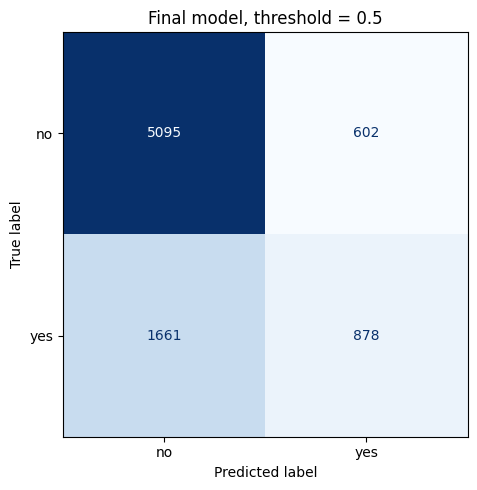

In [7]:
cm = confusion_matrix(y_test, test_preds)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm, display_labels=['no', 'yes']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Final model, threshold = 0.5')
plt.tight_layout()
plt.show()

In this project's terms:

- **True Negative** — the model correctly does not prioritize a customer who would not have subscribed.
- **False Positive** — the model prioritizes a customer who ultimately does not subscribe. A contact that didn't convert.
- **False Negative** — the model fails to prioritize a customer who would have subscribed. A missed opportunity.
- **True Positive** — the model correctly prioritizes a customer who does subscribe.

No specific dollar cost is attached to any of these — the dataset doesn't provide cost or revenue figures, so this stays qualitative. What's clear without inventing numbers: this project's stated objective (prioritizing scarce marketing resources) is more sensitive to false negatives than a generic classification problem would be, since each one represents a lost sale rather than just a labeling error — which is part of why threshold choice (Section 8 onward) matters beyond just picking the most "accurate" cutoff.

## 6. ROC Curve

ROC-AUC summarizes how well the model ranks subscribers above non-subscribers, averaged across every possible threshold.

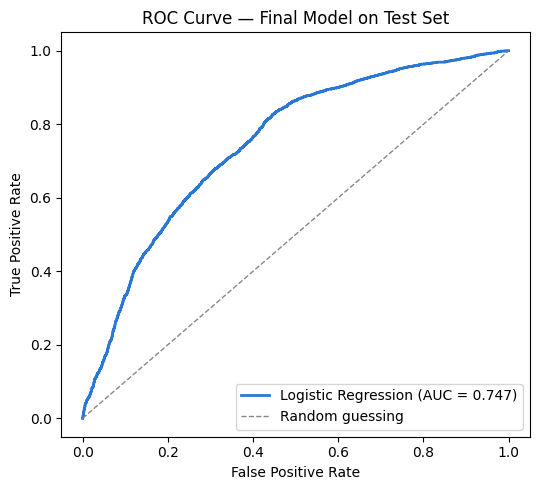

In [8]:
fpr, tpr, roc_thresholds = roc_curve(y_test, test_probs)
roc_auc = roc_auc_score(y_test, test_probs)

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(fpr, tpr, color=BLUE, linewidth=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
ax.plot([0, 1], [0, 1], color=MUTED, linestyle='--', linewidth=1, label='Random guessing')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Final Model on Test Set')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

An AUC of 0.75 means: given one random subscriber and one random non-subscriber from the test set, the model assigns the subscriber a higher probability about 75% of the time. That's a real, meaningfully-better-than-chance signal. **It does not, by itself, say anything about whether the model is useful for the business** — ROC-AUC ignores class balance and doesn't depend on any specific decision threshold, so a model can have a respectable ROC-AUC while still making poor decisions at the threshold actually used. That's exactly why Sections 7-10 don't stop here.

## 7. Precision-Recall Curve

Precision-Recall analysis focuses specifically on how well the model handles the positive (subscriber) class — the one this project actually cares about identifying.

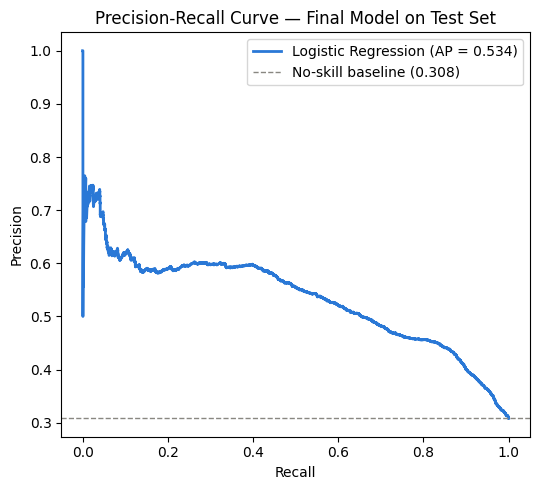

In [9]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, test_probs)
pr_auc = average_precision_score(y_test, test_probs)
baseline_rate = y_test.mean()

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.plot(recall_curve, precision_curve, color=BLUE, linewidth=2, label=f'Logistic Regression (AP = {pr_auc:.3f})')
ax.axhline(baseline_rate, color=MUTED, linestyle='--', linewidth=1, label=f'No-skill baseline ({baseline_rate:.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Final Model on Test Set')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

Average Precision of 0.53 summarizes precision across every recall level. The "no-skill" reference line here is the test period's own subscription rate (30.8%) — a classifier with no real signal would hug that line. The model sits clearly above it.

One honest note specific to this project: the usual reason to prefer PR-AUC over ROC-AUC is a *rare* positive class, and the overall dataset's positive rate is only 11.3% (6.4% in the training period). This particular test slice happens to have a much higher rate (30.8%) because of the chronological split — the class imbalance argument for PR-AUC applies more to the deployment scenario as a whole than to this specific test slice. PR-AUC is still used here for consistency with the rest of the project and because the model will ultimately be deployed on the true, rarer overall base rate, not this test period's unusually high one.

## 8. Threshold Analysis

**Methodology note.** The threshold used for `predict()` is not automatically the right one for this project — it's just scikit-learn's default. Choosing a threshold by sweeping it against the *test set* would mean using the test set to make a modeling decision, which notebook 06 already established should not happen. Instead, this section selects the threshold using **out-of-fold predictions on the training data only** — `cross_val_predict` refits the pipeline across the same 5 folds used throughout this project and returns, for every training row, a probability from a fold that never saw that row during fitting. This is a simple, standard way to get validation-quality predictions without touching the test set or building a separate validation split.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probs = cross_val_predict(final_pipeline, X_train, y_train, cv=cv, method='predict_proba')[:, 1]
oof_probs.shape

/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow 

/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear

/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: overflow 

/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/aaryansharma/bank-marketing-ml/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


(32940,)

In [11]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

rows = []
for t in thresholds:
    preds_t = (oof_probs >= t).astype(int)
    n_positive = preds_t.sum()
    rows.append({
        'threshold': t,
        'precision': precision_score(y_train, preds_t, zero_division=0),
        'recall': recall_score(y_train, preds_t),
        'f1': f1_score(y_train, preds_t),
        'n_predicted_positive': n_positive,
        'pct_predicted_positive': n_positive / len(y_train) * 100,
    })

threshold_table = pd.DataFrame(rows)
threshold_table.round(4)

,threshold,precision,recall,f1,n_predicted_positive,pct_predicted_positive
0,0.1,0.2121,0.3129,0.2528,3098,9.4050
1,0.2,0.3800,0.2081,0.2689,1150,3.4912
2,0.3,0.4612,0.1133,0.1820,516,1.5665
3,0.4,0.5060,0.0800,0.1382,332,1.0079
4,0.5,0.5357,0.0429,0.0794,168,0.5100
5,0.6,0.4828,0.0133,0.0259,58,0.1761
6,0.7,0.3333,0.0010,0.0019,6,0.0182
7,0.8,0.0000,0.0000,0.0000,0,0.0000
8,0.9,0.0000,0.0000,0.0000,0,0.0000


F1 peaks early (around 0.1-0.2) and falls off sharply after that, and by 0.8 the model predicts *zero* customers as positive. This makes sense given the training period's low 6.4% subscription rate: the model's predicted probabilities are calibrated to that low base rate, so relatively few training rows ever get a probability above 0.5, let alone 0.7 or 0.8. The standard 0.1-0.9 grid is too coarse to see exactly where F1 peaks — a closer look at the low end is worth it before deciding.

In [12]:
fine_thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30]

fine_rows = []
for t in fine_thresholds:
    preds_t = (oof_probs >= t).astype(int)
    n_positive = preds_t.sum()
    fine_rows.append({
        'threshold': t,
        'precision': precision_score(y_train, preds_t, zero_division=0),
        'recall': recall_score(y_train, preds_t),
        'f1': f1_score(y_train, preds_t),
        'n_predicted_positive': n_positive,
        'pct_predicted_positive': n_positive / len(y_train) * 100,
    })

fine_threshold_table = pd.DataFrame(fine_rows)
fine_threshold_table.round(4)

,threshold,precision,recall,f1,n_predicted_positive,pct_predicted_positive
0,0.05,0.0903,0.6733,0.1593,15651,47.5137
1,0.10,0.2121,0.3129,0.2528,3098,9.4050
2,0.15,0.2859,0.2729,0.2792,2004,6.0838
3,0.20,0.3800,0.2081,0.2689,1150,3.4912
4,0.25,0.4302,0.1438,0.2156,702,2.1311
5,0.30,0.4612,0.1133,0.1820,516,1.5665


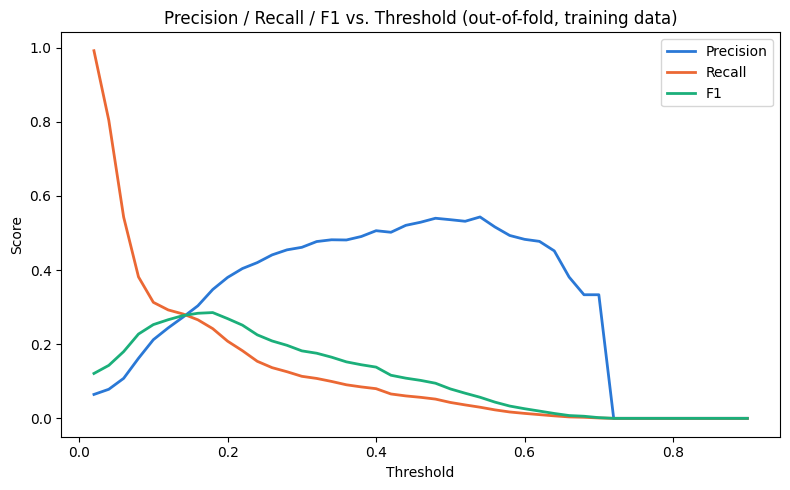

In [13]:
plot_thresholds = np.arange(0.02, 0.92, 0.02)
precisions, recalls, f1s = [], [], []
for t in plot_thresholds:
    preds_t = (oof_probs >= t).astype(int)
    precisions.append(precision_score(y_train, preds_t, zero_division=0))
    recalls.append(recall_score(y_train, preds_t))
    f1s.append(f1_score(y_train, preds_t))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(plot_thresholds, precisions, color=BLUE, linewidth=2, label='Precision')
ax.plot(plot_thresholds, recalls, color=ORANGE, linewidth=2, label='Recall')
ax.plot(plot_thresholds, f1s, color=AQUA, linewidth=2, label='F1')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 vs. Threshold (out-of-fold, training data)')
ax.legend()
plt.tight_layout()
plt.show()

The best F1 in the fine-grained table is at **threshold = 0.15** (F1 = 0.279). Below that, recall climbs but precision collapses quickly; above it, precision improves slowly while recall drops fast.

## 9. Business Trade-off

Using the out-of-fold table's actual numbers, not the highest F1 alone:

- **Lower threshold (e.g. 0.10)**: 9.4% of training customers prioritized, 31.3% recall, 21.2% precision. More customers get contacted, more of the real subscribers are caught, but roughly 4 in 5 prioritized customers don't subscribe.
- **Threshold 0.15**: 6.1% of customers prioritized, 27.3% recall, 28.6% precision. A more selective list with a similar catch rate to 0.10 and meaningfully better precision.
- **Higher threshold (e.g. 0.30)**: 1.6% of customers prioritized, only 11.3% recall, 46.1% precision. A short, higher-quality list, but the model would miss roughly 9 in 10 real subscribers.

The project's objective is prioritization under limited marketing resources, not maximum accuracy. A missed subscriber (false negative) is a lost opportunity, while a wasted contact (false positive) costs some marketing effort but not a lost sale — so, without inventing specific dollar figures, this project treats recall as slightly more important than precision when the two are close, consistent with the reasoning already used in notebook 05. That favors a threshold on the lower side of the range that still has reasonable precision, rather than the higher end where the model would miss the large majority of actual subscribers.

## 10. Selected Operating Threshold

**Selected threshold: 0.15.**

This is the best-F1 threshold found in Section 8's out-of-fold analysis — chosen because it balances precision and recall better than any other value tested, not chosen arbitrarily. It is also consistent with Section 9's business reasoning: it sits on the recall-favoring side of the curve without going as low as 0.10, where precision becomes very weak.

**This decision was made entirely from training-data cross-validation, without looking at the test set.** The test set is used below, for the first and only time in this notebook, to report how that pre-selected threshold actually performs.

## 11. Final Model Performance

Applying the threshold chosen in Section 10 to the test-set probabilities already generated in Section 3.

In [14]:
chosen_threshold = 0.15
final_preds = (test_probs >= chosen_threshold).astype(int)

print('accuracy: ', accuracy_score(y_test, final_preds))
print('precision:', precision_score(y_test, final_preds))
print('recall:   ', recall_score(y_test, final_preds))
print('f1:       ', f1_score(y_test, final_preds))

accuracy:  0.644851869839728
precision: 0.4562754870865428
recall:    0.7932256794013391
f1:        0.5793182798791888


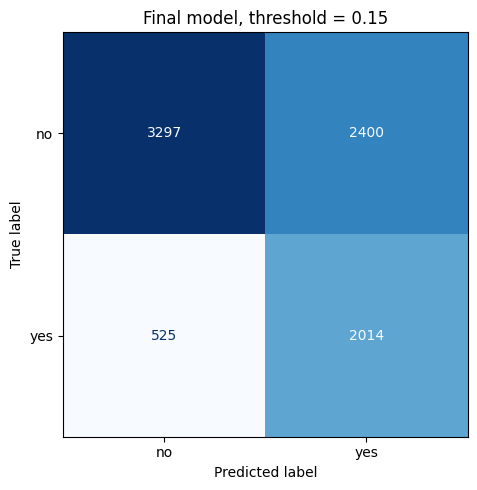

In [15]:
cm_final = confusion_matrix(y_test, final_preds)
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(cm_final, display_labels=['no', 'yes']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Final model, threshold = {chosen_threshold}')
plt.tight_layout()
plt.show()

In [16]:
total_customers = len(y_test)
n_selected = final_preds.sum()
true_positives = ((final_preds == 1) & (y_test == 1)).sum()
false_negatives = ((final_preds == 0) & (y_test == 1)).sum()
total_actual_subscribers = y_test.sum()

print('total test customers:', total_customers)
print('customers prioritized:', n_selected, f'({n_selected / total_customers:.1%})')
print('actual subscribers among prioritized customers:', true_positives)
print('precision among prioritized customers:', true_positives / n_selected)
print('actual subscribers missed:', false_negatives)
print('percent of actual subscribers captured:', true_positives / total_actual_subscribers)

total test customers: 8236
customers prioritized: 4414 (53.6%)
actual subscribers among prioritized customers: 2014
precision among prioritized customers: 0.4562754870865428
actual subscribers missed: 525
percent of actual subscribers captured: 0.7932256794013391


**At this threshold, the model would prioritize about 54% of test customers and capture about 79% of the actual subscribers in the evaluation sample.**

That's an honest, slightly uncomfortable result worth sitting with rather than glossing over: 54% is a large share of the customer base to call "prioritized" — not far from calling everyone. This traces directly back to the train/test distribution shift flagged repeatedly in notebooks 05-06. The threshold was tuned to be F1-optimal on the *training* period's probability distribution, where the base rate was only 6.4%; the *test* period's rate is 30.8%, and this model happens to output meaningfully higher probabilities across the test period overall, so the same cutoff selects a much larger fraction of it. This isn't the result changing after the fact — the threshold was fixed in Section 10 before this section ran — it's a real limitation of validating a threshold under one distribution and applying it under another. See Section 12.

In [17]:
baseline_accuracy = (y_test == 0).mean()

summary_comparison = pd.DataFrame({
    'Majority baseline': {'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'accuracy': baseline_accuracy, 'pct_customers_selected': 0.0},
    'Final model @ 0.5': {
        'precision': precision_score(y_test, test_preds),
        'recall': recall_score(y_test, test_preds),
        'f1': f1_score(y_test, test_preds),
        'accuracy': accuracy_score(y_test, test_preds),
        'pct_customers_selected': test_preds.sum() / total_customers * 100,
    },
    'Final model @ 0.15 (selected)': {
        'precision': precision_score(y_test, final_preds),
        'recall': recall_score(y_test, final_preds),
        'f1': f1_score(y_test, final_preds),
        'accuracy': accuracy_score(y_test, final_preds),
        'pct_customers_selected': n_selected / total_customers * 100,
    },
}).T
summary_comparison.round(4)

,precision,recall,f1,accuracy,pct_customers_selected
Majority baseline,0.0000,0.0000,0.0000,0.6917,0.0000
Final model @ 0.5,0.5932,0.3458,0.4369,0.7252,17.9699
Final model @ 0.15 (selected),0.4563,0.7932,0.5793,0.6449,53.5940


Against the majority baseline, the model is unambiguously useful: it captures real subscribers the baseline captures none of, at both thresholds. Against itself at the default threshold, the 0.15 cutoff trades a large amount of precision and some accuracy for a substantial recall gain (0.35 to 0.79) — consistent with the business reasoning in Section 9, though the scale of the trade (more than half the customer base selected) is larger than ideal, for the reason explained above. `Final model @ 0.15` is what this project reports as its recommended operating point, with that limitation explicitly acknowledged rather than hidden.

## 12. Limitations

- **Train/test distribution shift.** The chronological split (necessary to avoid an unrealistic evaluation, per notebook 05) means the training period (6.4% subscription rate) and test period (30.8%) are genuinely different regimes. This affects raw metrics and, as Section 11 showed concretely, how well a validation-chosen threshold transfers.
- **Single train/test split, not a rolling evaluation.** A more rigorous temporal validation would use multiple sequential train/test splits (walk-forward validation) to see whether performance is stable across different points in time, not just one. That was out of scope for this project's complexity budget.
- **Historical data.** This dataset covers 2008-2010, a specific economic period (the global financial crisis and its aftermath). Customer behavior and banking practices since then have changed; this model reflects that historical window, not necessarily current conditions.
- **No cost or revenue data.** The threshold in Section 10 was chosen using F1 and general reasoning about which error type matters more, not an actual cost-benefit calculation, because the dataset provides no monetary figures. A bank with real cost-per-contact and revenue-per-subscription numbers could choose a more precisely optimal threshold.
- **Limited model search.** Only four model families were compared (notebook 05) and only two were tuned (notebook 06), each with a modest hyperparameter search space. A larger search might find something better, though notebook 06 already showed that more tuning effort doesn't automatically produce a meaningfully better result here.
- **Out-of-fold threshold selection is a training-data proxy, not a guarantee.** It correctly avoided using the test set to pick the threshold, but Section 11 shows it still doesn't perfectly anticipate test-period behavior, because the two periods have different underlying distributions. This is disclosed rather than hidden, per this notebook's methodology.

## Final Evaluation Summary

1. **Final model**: Logistic Regression (scikit-learn `LogisticRegression`).
2. **Final hyperparameters**: `C=1`, `class_weight=None`, `max_iter=1000`, `random_state=42` — confirmed optimal within notebook 06's search space, not manually chosen.
3. **Test Accuracy** (at threshold 0.15): 0.6449.
4. **Test Precision**: 0.4563.
5. **Test Recall**: 0.7932.
6. **Test F1**: 0.5793.
7. **Test ROC-AUC**: 0.7473 (threshold-independent).
8. **Test PR-AUC / Average Precision**: 0.5339 (threshold-independent).
9. **Selected threshold**: 0.15, chosen via out-of-fold cross-validation on training data only, before the test set was examined.
10. **Customers prioritized**: about 54% of the test set (4,414 of 8,236 customers).
11. **Subscribers captured**: about 79% of actual test-set subscribers (2,014 of 2,539).
12. **Business trade-off**: this threshold favors recall over precision, consistent with treating a missed subscriber as a worse outcome than a wasted contact — but it selects a larger share of the customer base than a "prioritization" framing ideally implies, a direct consequence of the train/test distribution shift documented in Section 11 and Section 12.
13. **Limitations**: single chronological train/test split rather than rolling validation; historical 2008-2010 data; no real cost/revenue figures to optimize against; a modest model and hyperparameter search; and a validation-chosen threshold that, while methodologically sound, did not transfer perfectly across the documented distribution shift.

**Honest bottom line**: the final model provides a real, meaningfully-better-than-baseline signal (ROC-AUC 0.75, PR-AUC 0.53) and, at the selected threshold, captures most actual subscribers in this test sample — but at the cost of a broad, only moderately precise contact list rather than a narrowly "prioritized" one. That trade-off, and the distribution shift behind it, are reported directly rather than smoothed over. The model and threshold are not changed based on this result — this evaluation is final for this notebook.